In [1]:
import json
import pickle
from typing import cast

import matplotlib.pyplot as plt
import pandas as pd

from aare.evaluation.forecast import Forecast
from aare.evaluation.metrics import Metrics
from aare.utils import LAST_FORECASTS_FOLDER, METRICS_FOLDER

plt.rcParams["figure.figsize"] = (16, 9)

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
def plot_from_file(path, title: str):
    with open(path, "rb") as file:
        forecast = cast(Forecast, pickle.load(file))
    return forecast.plot(title)

In [4]:
def plot_baseline(model: str):
    plot_from_file(LAST_FORECASTS_FOLDER / f"{model}.pkl", model)

In [5]:
def read_metrics(path, as_dict=False):
    with open(path, "rt") as file:
        raw = json.load(file)
        if as_dict:
            return raw

        return Metrics.from_dict(raw)

In [6]:
def combine_metrics(*models: str):
    metrics = []
    for model in models:
        metrics.append(read_metrics(METRICS_FOLDER / f"{model}.json", as_dict=True) | dict(name=model))

    return pd.DataFrame(metrics).set_index("name")

In [7]:
combine_metrics("LOCF", "MEAN", "SNAIVE", "TIMESFM")

,mae,rmse
name,,
LOCF,0.881175,1.042479
MEAN,0.921450,1.072696
SNAIVE,0.771717,0.909252
TIMESFM,0.711422,0.841295


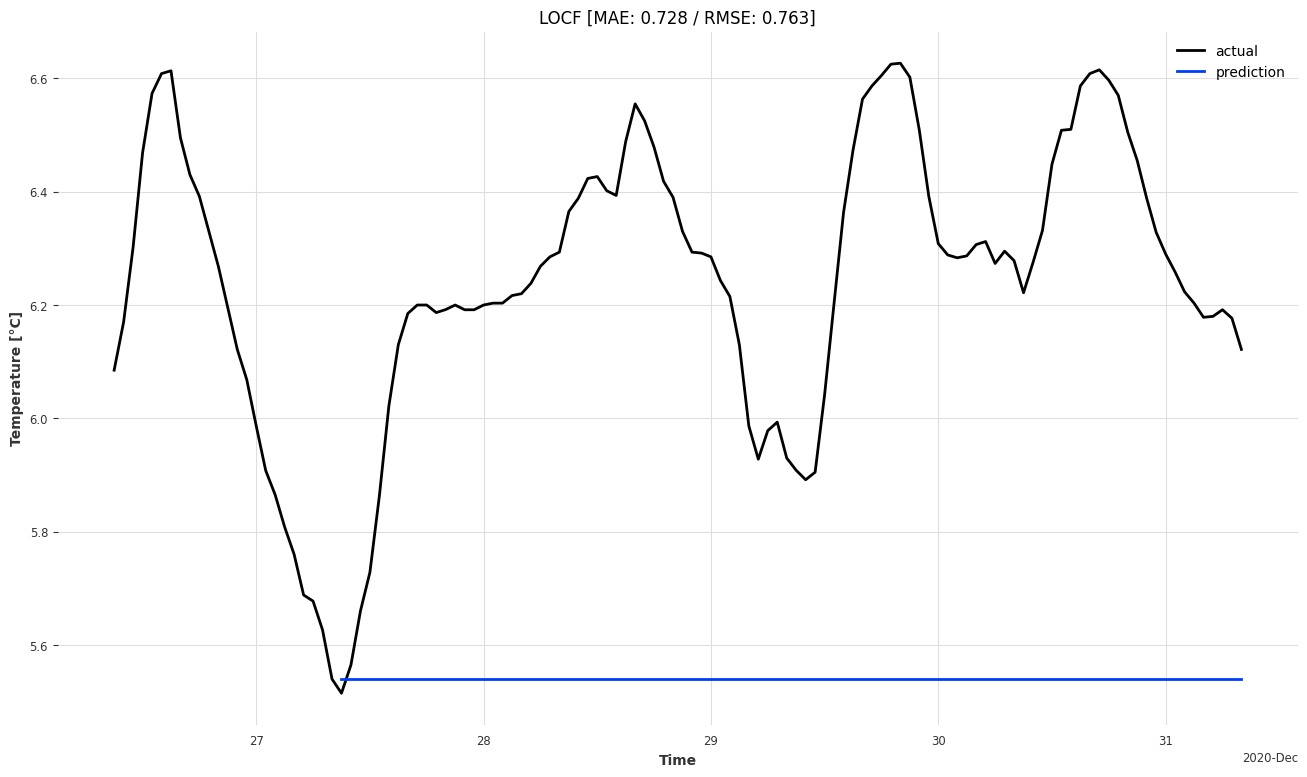

In [8]:
plot_baseline("LOCF")

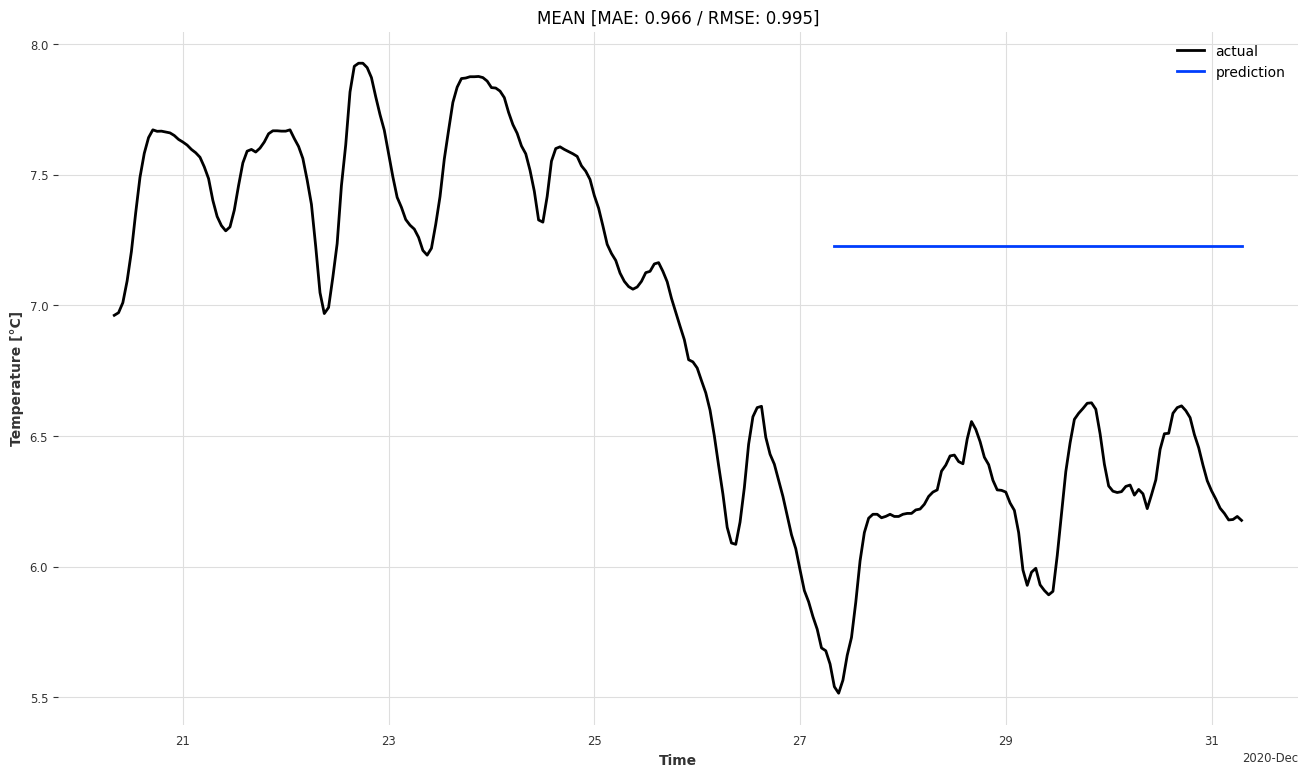

In [9]:
plot_baseline("MEAN")

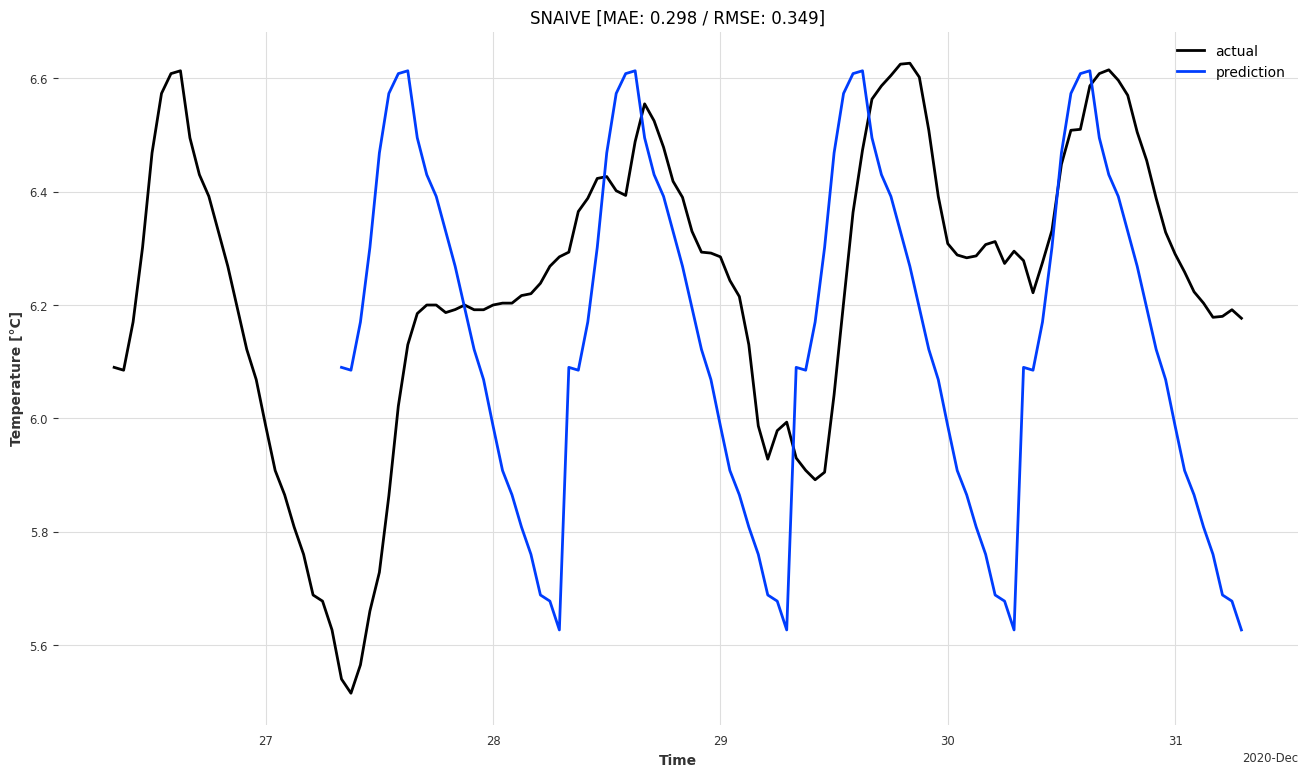

In [10]:
plot_baseline("SNAIVE")

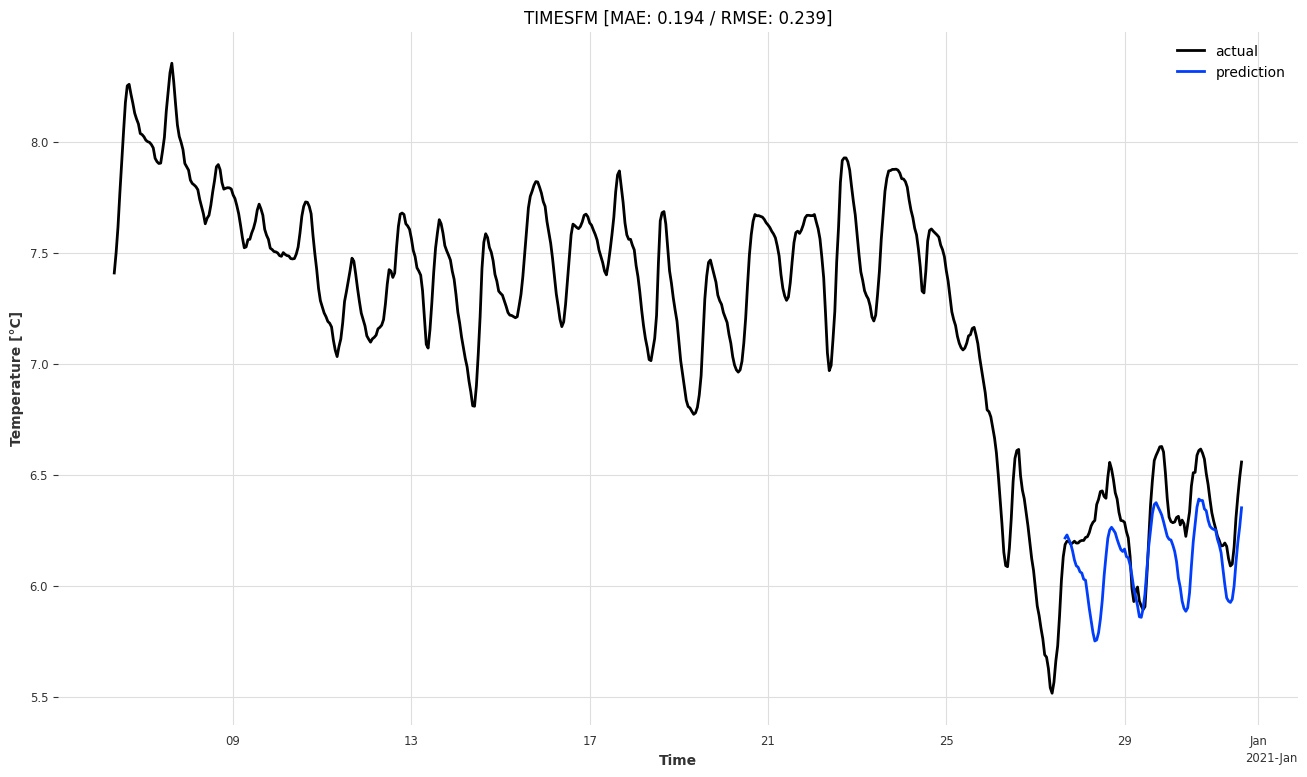

In [11]:
plot_baseline("TIMESFM")